In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("superstore.csv")

In [5]:
print(df.head())
print(df.shape)
print(df.columns)

  Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0      1  CA-2017-152156   11/8/2017  11/11/2017    Second Class    CG-12520   
1      2  CA-2017-152156   11/8/2017  11/11/2017    Second Class    CG-12520   
2      3  CA-2017-138688   6/12/2017   6/16/2017    Second Class    DV-13045   
3      4  US-2016-108966  10/11/2016  10/18/2016  Standard Class    SO-20335   
4      5  US-2016-108966  10/11/2016  10/18/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0     42420.0   South  FUR

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  object 
 1   Order ID       10800 non-null  object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quanti

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(df['Order Date'].dtype)
print(df[['Order Date', 'Sales']].head())

datetime64[ns]
  Order Date     Sales
0 2017-11-08  261.9600
1 2017-11-08  731.9400
2 2017-06-12   14.6200
3 2016-10-11  957.5775
4 2016-10-11   22.3680


In [8]:
print(df['Order Date'].min())
print(df['Order Date'].max())

2015-01-03 00:00:00
2018-12-30 00:00:00


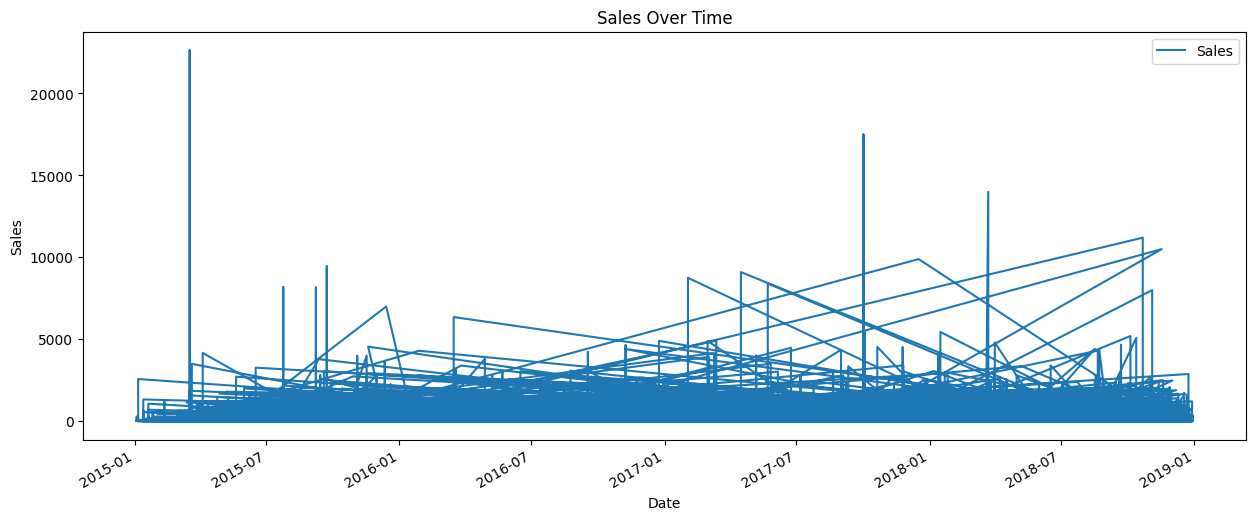

In [9]:
df.plot(
    x='Order Date',
    y='Sales',
    figsize=(15, 6)
)

plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()


In [10]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

In [11]:
print(daily_sales.head(10))
print(daily_sales.shape)

  Order Date     Sales
0 2015-01-03    16.448
1 2015-01-04   288.060
2 2015-01-05    19.536
3 2015-01-06  4407.100
4 2015-01-07    87.158
5 2015-01-09    40.544
6 2015-01-10    54.830
7 2015-01-11     9.940
8 2015-01-13  3553.795
9 2015-01-14    61.960
(1236, 2)


In [12]:
print(daily_sales['Order Date'].min())
print(daily_sales['Order Date'].max())

2015-01-03 00:00:00
2018-12-30 00:00:00


In [13]:
date_range = pd.date_range(
    start=daily_sales['Order Date'].min(),
    end=daily_sales['Order Date'].max(),
    freq='D'
)

print("Expected days:", len(date_range))
print("Actual days:", len(daily_sales))
print("Missing days:", len(date_range) - len(daily_sales))

Expected days: 1458
Actual days: 1236
Missing days: 222


In [14]:
missing_dates = date_range.difference(daily_sales['Order Date'])

print(missing_dates[:20])

DatetimeIndex(['2015-01-08', '2015-01-12', '2015-01-17', '2015-01-22',
               '2015-01-24', '2015-01-25', '2015-01-29', '2015-02-05',
               '2015-02-09', '2015-02-10', '2015-02-13', '2015-02-19',
               '2015-02-25', '2015-02-26', '2015-02-28', '2015-03-06',
               '2015-03-08', '2015-03-09', '2015-03-12', '2015-03-13'],
              dtype='datetime64[ns]', freq=None)


In [15]:
daily_sales = daily_sales.set_index('Order Date')

In [16]:
daily_sales = daily_sales.asfreq('D', fill_value=0)

In [17]:
print(daily_sales.head(10))
print(daily_sales.shape)
print(daily_sales.isnull().sum())

               Sales
Order Date          
2015-01-03    16.448
2015-01-04   288.060
2015-01-05    19.536
2015-01-06  4407.100
2015-01-07    87.158
2015-01-08     0.000
2015-01-09    40.544
2015-01-10    54.830
2015-01-11     9.940
2015-01-12     0.000
(1458, 1)
Sales    0
dtype: int64


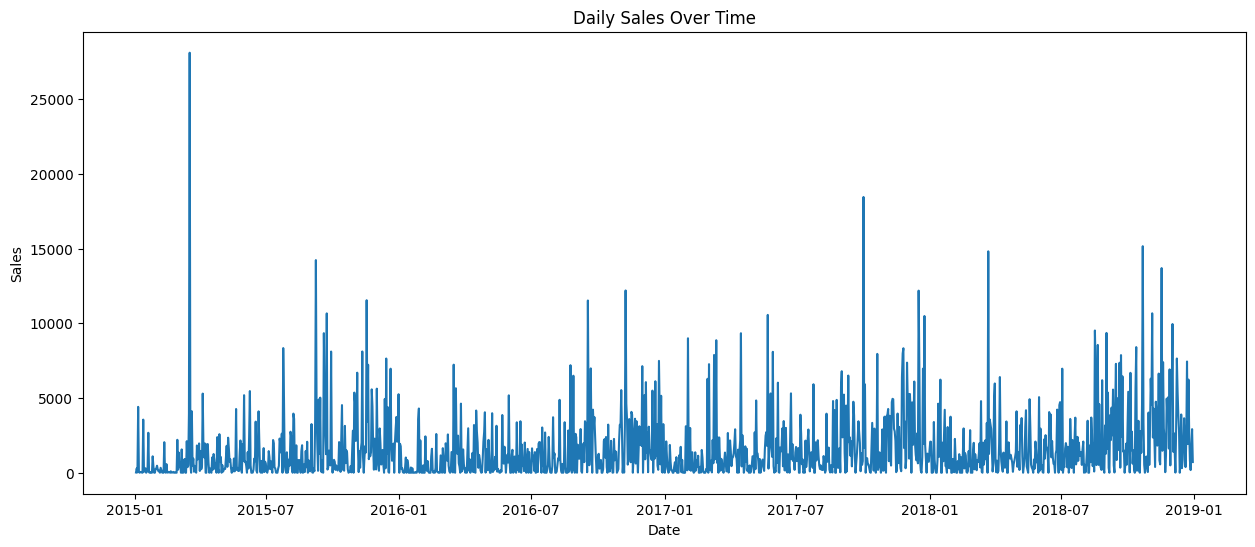

In [18]:
plt.figure(figsize=(15, 6))

plt.plot(daily_sales.index, daily_sales['Sales'])

plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()


In [19]:
monthly_sales = daily_sales['Sales'].resample('ME').sum()

print(monthly_sales.head())

Order Date
2015-01-31    14236.895
2015-02-28     4519.892
2015-03-31    55691.009
2015-04-30    28295.345
2015-05-31    23648.287
Freq: ME, Name: Sales, dtype: float64


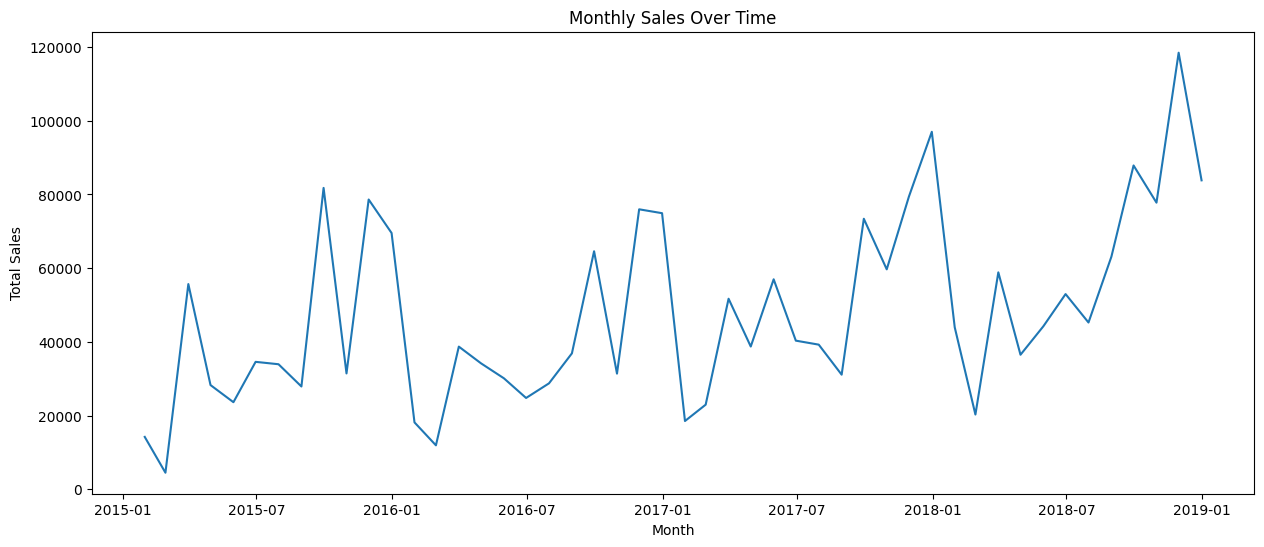

In [20]:
plt.figure(figsize=(15, 6))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.title('Monthly Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.show()

In [21]:
daily_sales['Year'] = daily_sales.index.year
daily_sales['Month'] = daily_sales.index.month
daily_sales['Day'] = daily_sales.index.day
daily_sales['DayOfWeek'] = daily_sales.index.dayofweek
daily_sales['WeekOfYear'] = daily_sales.index.isocalendar().week

In [22]:
print(daily_sales.head())

               Sales  Year  Month  Day  DayOfWeek  WeekOfYear
Order Date                                                   
2015-01-03    16.448  2015      1    3          5           1
2015-01-04   288.060  2015      1    4          6           1
2015-01-05    19.536  2015      1    5          0           2
2015-01-06  4407.100  2015      1    6          1           2
2015-01-07    87.158  2015      1    7          2           2


In [23]:
daily_sales['Lag_1'] = daily_sales['Sales'].shift(1)
daily_sales['Lag_2'] = daily_sales['Sales'].shift(2)
daily_sales['Lag_7'] = daily_sales['Sales'].shift(7)
daily_sales['Lag_14'] = daily_sales['Sales'].shift(14)
daily_sales['Lag_30'] = daily_sales['Sales'].shift(30)

In [24]:
print(daily_sales[['Sales', 'Lag_1', 'Lag_2', 'Lag_7', 'Lag_14', 'Lag_30']].head(35))

               Sales     Lag_1     Lag_2     Lag_7    Lag_14    Lag_30
Order Date                                                            
2015-01-03    16.448       NaN       NaN       NaN       NaN       NaN
2015-01-04   288.060    16.448       NaN       NaN       NaN       NaN
2015-01-05    19.536   288.060    16.448       NaN       NaN       NaN
2015-01-06  4407.100    19.536   288.060       NaN       NaN       NaN
2015-01-07    87.158  4407.100    19.536       NaN       NaN       NaN
2015-01-08     0.000    87.158  4407.100       NaN       NaN       NaN
2015-01-09    40.544     0.000    87.158       NaN       NaN       NaN
2015-01-10    54.830    40.544     0.000    16.448       NaN       NaN
2015-01-11     9.940    54.830    40.544   288.060       NaN       NaN
2015-01-12     0.000     9.940    54.830    19.536       NaN       NaN
2015-01-13  3553.795     0.000     9.940  4407.100       NaN       NaN
2015-01-14    61.960  3553.795     0.000    87.158       NaN       NaN
2015-0

In [25]:
print(daily_sales.shape)
print(daily_sales.isnull().sum())

(1458, 11)
Sales          0
Year           0
Month          0
Day            0
DayOfWeek      0
WeekOfYear     0
Lag_1          1
Lag_2          2
Lag_7          7
Lag_14        14
Lag_30        30
dtype: int64


In [26]:
features = [
    'Year',
    'Month',
    'Day',
    'DayOfWeek',
    'WeekOfYear',
    'Lag_1',
    'Lag_2',
    'Lag_7',
    'Lag_14',
    'Lag_30'
]

X = daily_sales[features]
y = daily_sales['Sales']

In [27]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1458, 10)
y shape: (1458,)


In [28]:
split_index = int(len(daily_sales) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [29]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("Training period:")
print(X_train.index.min(), "to", X_train.index.max())

print("Testing period:")
print(X_test.index.min(), "to", X_test.index.max())

Training data: (1166, 10)
Testing data: (292, 10)
Training period:
2015-01-03 00:00:00 to 2018-03-13 00:00:00
Testing period:
2018-03-14 00:00:00 to 2018-12-30 00:00:00


In [31]:
print(X_train.isna().sum())

Year           0
Month          0
Day            0
DayOfWeek      0
WeekOfYear     0
Lag_1          1
Lag_2          2
Lag_7          7
Lag_14        14
Lag_30        30
dtype: int64


In [32]:
print(y_train.isna().sum())

0


In [33]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

In [34]:
print(X_train.isna().sum())
print(y_train.isna().sum())

Year          0
Month         0
Day           0
DayOfWeek     0
WeekOfYear    0
Lag_1         0
Lag_2         0
Lag_7         0
Lag_14        0
Lag_30        0
dtype: int64
0


In [35]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [36]:
y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [37]:
print(y_pred[:10])

[1257.4590739  1086.40764776 1140.0210648  1316.51574886 1167.69843836
 1110.27249084 1755.91757892 1022.89912041 1151.35242556 1265.03255293]


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 1704.0552685798373
MSE: 6020540.915230995
R² Score: 0.05198818661133908


In [39]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [40]:
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions completed!")

Random Forest predictions completed!


In [41]:
print(rf_pred[:10])

[1897.58015  2305.51576  2460.247932 1886.387793 1826.008006 1868.888865
 1349.94201   827.441325  728.9215   1729.187115]


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest R² Score:", rf_r2)

Random Forest MAE: 1605.4666163801369
Random Forest MSE: 5672919.524914699
Random Forest R² Score: 0.1067256577532979


In [43]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

      Feature  Importance
7       Lag_7    0.173951
5       Lag_1    0.140430
9      Lag_30    0.139341
8      Lag_14    0.126028
6       Lag_2    0.094246
2         Day    0.090085
4  WeekOfYear    0.089259
1       Month    0.066061
3   DayOfWeek    0.050728
0        Year    0.029871


In [44]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "MSE": [mse, rf_mse],
    "R2": [r2, rf_r2]
})

print(comparison)

               Model          MAE           MSE        R2
0  Linear Regression  1704.055269  6.020541e+06  0.051988
1      Random Forest  1605.466616  5.672920e+06  0.106726


In [45]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (1136, 10)
X_test: (292, 10)
y_train: (1136,)
y_test: (292,)


In [46]:
print("Training period:")
print(df.loc[X_train.index, "Order Date"].min())
print(df.loc[X_train.index, "Order Date"].max())

print("\nTesting period:")
print(df.loc[X_test.index, "Order Date"].min())
print(df.loc[X_test.index, "Order Date"].max())

Training period:


KeyError: "None of [DatetimeIndex(['2015-02-02', '2015-02-03', '2015-02-04', '2015-02-05',\n               '2015-02-06', '2015-02-07', '2015-02-08', '2015-02-09',\n               '2015-02-10', '2015-02-11',\n               ...\n               '2018-03-04', '2018-03-05', '2018-03-06', '2018-03-07',\n               '2018-03-08', '2018-03-09', '2018-03-10', '2018-03-11',\n               '2018-03-12', '2018-03-13'],\n              dtype='datetime64[ns]', name='Order Date', length=1136, freq='D')] are in the [index]"

In [47]:
print("Training period:")
print(X_train.index.min())
print(X_train.index.max())

print("\nTesting period:")
print(X_test.index.min())
print(X_test.index.max())

Training period:
2015-02-02 00:00:00
2018-03-13 00:00:00

Testing period:
2018-03-14 00:00:00
2018-12-30 00:00:00


In [48]:
from sklearn.ensemble import RandomForestRegressor

rf_model_2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model_2.fit(X_train, y_train)

print("Improved Random Forest training completed!")

Improved Random Forest training completed!


In [49]:
rf_pred_2 = rf_model_2.predict(X_test)

print("Predictions completed!")
print(rf_pred_2[:10])

Predictions completed!
[1886.89529262 1889.71765821 2134.50745187 1658.09111318 1801.13674461
 1861.71946137 1318.63096719 1035.41019598  806.98368875 1651.60423485]


In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_mae_2 = mean_absolute_error(y_test, rf_pred_2)
rf_mse_2 = mean_squared_error(y_test, rf_pred_2)
rf_r2_2 = r2_score(y_test, rf_pred_2)

print("Improved Random Forest MAE:", rf_mae_2)
print("Improved Random Forest MSE:", rf_mse_2)
print("Improved Random Forest R2:", rf_r2_2)

Improved Random Forest MAE: 1573.7514951779547
Improved Random Forest MSE: 5570311.458250074
Improved Random Forest R2: 0.12288262117513093


In [51]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting training completed!")

Gradient Boosting training completed!


In [52]:
gb_pred = gb_model.predict(X_test)

print("Predictions completed!")
print(gb_pred[:10])


Predictions completed!
[4617.76664749 1847.88576649 2016.89329339 1663.22500055 1181.51632878
 1689.14753463 1422.08861778 1191.2263916   455.85359373 1593.74752329]


In [53]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting MSE:", gb_mse)
print("Gradient Boosting R2:", gb_r2)

Gradient Boosting MAE: 1647.3881233371026
Gradient Boosting MSE: 6151294.651736097
Gradient Boosting R2: 0.031399324481367175


In [54]:
import joblib

joblib.dump(rf_model_2, "sales_forecasting_model.pkl")

print("Best model saved successfully!")


Best model saved successfully!


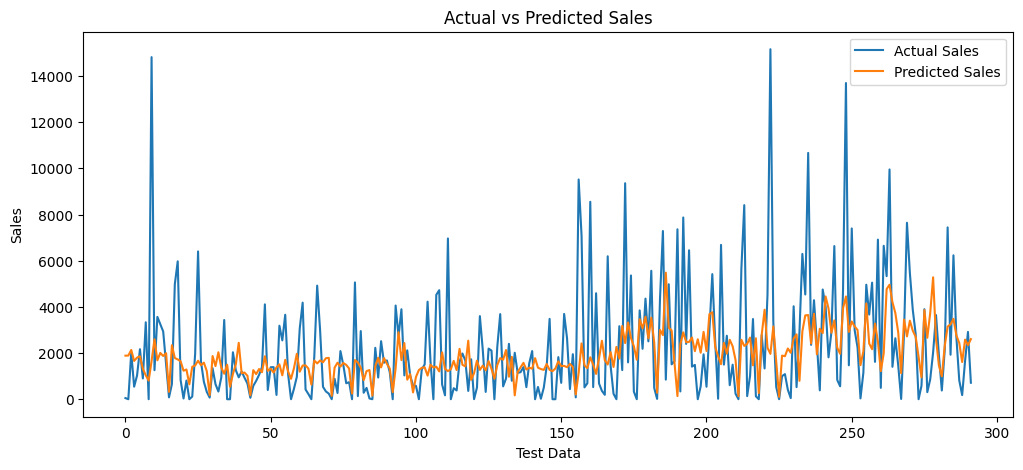

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(y_test.values, label="Actual Sales")
plt.plot(rf_pred_2, label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Data")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [56]:
errors = y_test.values - rf_pred_2

print("Mean Error:", errors.mean())
print("Maximum Error:", errors.max())
print("Minimum Error:", errors.min())

Mean Error: 313.6745035561021
Maximum Error: 13196.19415523616
Minimum Error: -4632.393612845554


In [57]:
error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_pred_2,
    "Error": errors
}, index=y_test.index)

error_analysis["Absolute_Error"] = abs(error_analysis["Error"])

print(error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
).head(10))

                Actual    Predicted         Error  Absolute_Error
Order Date                                                       
2018-10-22  15158.8770  1962.682845  13196.194155    13196.194155
2018-03-23  14816.0680  1651.604235  13164.463765    13164.463765
2018-11-17  13694.8828  4449.690830   9245.191970     9245.191970
2018-08-17   9517.2880  1145.601567   8371.686433     8371.686433
2018-09-20   7359.9180   136.154300   7223.763700     7223.763700
2018-11-04  10668.0960  3645.260911   7022.835089     7022.835089
2018-09-02   9354.8540  2430.833263   6924.020737     6924.020737
2018-08-21   8551.0540  1817.442615   6733.611385     6733.611385
2018-10-13   8405.8020  2309.640114   6096.161886     6096.161886
2018-07-03   6963.4040  1216.992850   5746.411150     5746.411150


In [58]:
print(
    df.loc[
        "2018-10-15":"2018-10-29",
        ["Sales"]
    ]
)

Empty DataFrame
Columns: [Sales]
Index: []


In [59]:
print(
    y_test.loc[
        "2018-10-15":"2018-10-29"
    ]
)

Order Date
2018-10-15     1017.9400
2018-10-16     3473.5970
2018-10-17      126.3520
2018-10-18        0.0000
2018-10-19     2781.8702
2018-10-20     1333.8580
2018-10-21     4537.2010
2018-10-22    15158.8770
2018-10-23     3352.3940
2018-10-24      529.0850
2018-10-25        0.0000
2018-10-26      999.8680
2018-10-27     1086.3200
2018-10-28      408.7260
2018-10-29       46.9600
Freq: D, Name: Sales, dtype: float64


In [60]:
print("Sales statistics:")
print(y_train.describe())

Sales statistics:
count     1136.000000
mean      1434.279410
std       2128.557548
min          0.000000
25%         92.655000
50%        762.581000
75%       1939.183000
max      28106.716000
Name: Sales, dtype: float64


In [61]:
print("\nDays with sales above 5000:")
print((y_train > 5000).sum())


Days with sales above 5000:
69


In [62]:
normal_days = y_test <= 5000
high_days = y_test > 5000

normal_mae = mean_absolute_error(
    y_test[normal_days],
    rf_pred_2[normal_days]
)

high_mae = mean_absolute_error(
    y_test[high_days],
    rf_pred_2[high_days]
)

print("Normal-day MAE:", normal_mae)
print("High-sales-day MAE:", high_mae)
print("High-sales days in test set:", high_days.sum())

Normal-day MAE: 1104.701169243933
High-sales-day MAE: 5017.921031322056
High-sales days in test set: 35


In [63]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

y_train_log = np.log1p(y_train)

rf_log = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_log.fit(X_train, y_train_log)

print("Log-transformed Random Forest training completed!")

Log-transformed Random Forest training completed!


In [64]:
log_pred = rf_log.predict(X_test)

rf_log_pred = np.expm1(log_pred)

print("Predictions completed!")
print(rf_log_pred[:10])

Predictions completed!
[ 408.87077504   13.21580034 1039.84400967 1010.16860513  431.43327706
  670.2847822   474.43449422  404.25603502   69.07619519  488.52633259]


In [65]:
rf_log_mae = mean_absolute_error(y_test, rf_log_pred)
rf_log_mse = mean_squared_error(y_test, rf_log_pred)
rf_log_r2 = r2_score(y_test, rf_log_pred)

print("Log RF MAE:", rf_log_mae)
print("Log RF MSE:", rf_log_mse)
print("Log RF R2:", rf_log_r2)

Log RF MAE: 1662.2967253457516
Log RF MSE: 7573100.531578688
Log RF R2: -0.1924823481813489


In [66]:
final_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Improved Random Forest",
        "Gradient Boosting",
        "Log Random Forest"
    ],
    "MAE": [
        mae,
        rf_mae,
        rf_mae_2,
        gb_mae,
        rf_log_mae
    ],
    "MSE": [
        mse,
        rf_mse,
        rf_mse_2,
        gb_mse,
        rf_log_mse
    ],
    "R2": [
        r2,
        rf_r2,
        rf_r2_2,
        gb_r2,
        rf_log_r2
    ]
})

print(final_comparison.sort_values("R2", ascending=False))

                    Model          MAE           MSE        R2
2  Improved Random Forest  1573.751495  5.570311e+06  0.122883
1           Random Forest  1605.466616  5.672920e+06  0.106726
0       Linear Regression  1704.055269  6.020541e+06  0.051988
3       Gradient Boosting  1647.388123  6.151295e+06  0.031399
4       Log Random Forest  1662.296725  7.573101e+06 -0.192482


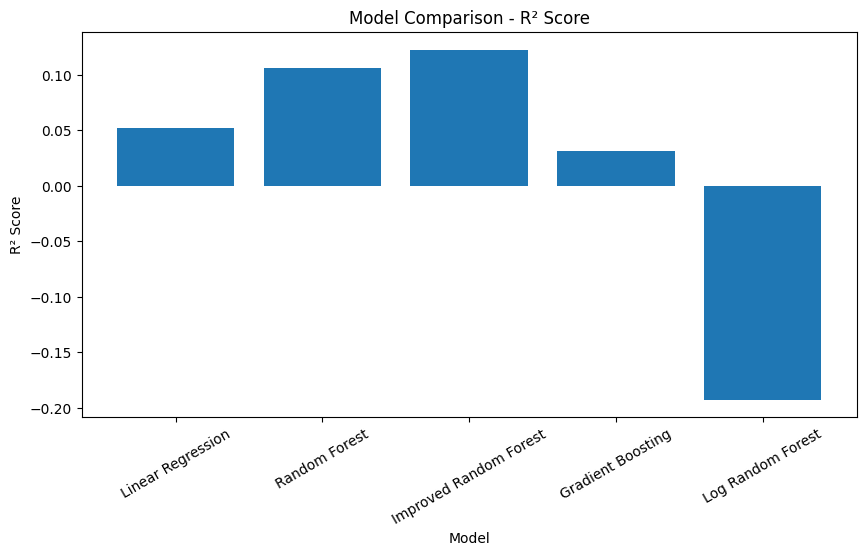

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["R2"]
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=30)

plt.show()

In [68]:
final_comparison.to_csv("model_comparison.csv", index=False)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [69]:
final_comparison.to_csv("model_comparison.csv", index=False)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [70]:
import os

print("Model file exists:", os.path.exists("sales_forecasting_model.pkl"))
print("Comparison file exists:", os.path.exists("model_comparison.csv"))

Model file exists: True
Comparison file exists: True


In [71]:
print("===== PROJECT SUMMARY =====")

print("Dataset shape:", df.shape)

print("\nFeatures:")
print(list(X_train.columns))

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nBest Model: Improved Random Forest")
print("MAE:", rf_mae_2)
print("MSE:", rf_mse_2)
print("R2:", rf_r2_2)

print("\nTraining period:")
print(X_train.index.min(), "to", X_train.index.max())

print("\nTesting period:")
print(X_test.index.min(), "to", X_test.index.max())

===== PROJECT SUMMARY =====
Dataset shape: (10800, 21)

Features:
['Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'Lag_1', 'Lag_2', 'Lag_7', 'Lag_14', 'Lag_30']

Training data: (1136, 10)
Testing data: (292, 10)

Best Model: Improved Random Forest
MAE: 1573.7514951779547
MSE: 5570311.458250074
R2: 0.12288262117513093

Training period:
2015-02-02 00:00:00 to 2018-03-13 00:00:00

Testing period:
2018-03-14 00:00:00 to 2018-12-30 00:00:00


In [72]:
readme = """
# Sales Forecasting Using Machine Learning

## Project Overview

This project focuses on forecasting daily sales using machine learning techniques.
Historical sales data was cleaned, transformed into a time-series dataset, and used
to train and compare multiple regression models.

The main objective was to understand how historical sales patterns and calendar-based
features can be used to predict future sales.

## Dataset

- Dataset shape: 10,800 rows × 21 columns
- Target variable: Sales
- Data frequency: Daily
- Training period: 2015-02-02 to 2018-03-13
- Testing period: 2018-03-14 to 2018-12-30

## Features

The following features were used:

- Year
- Month
- Day
- DayOfWeek
- WeekOfYear
- Lag_1
- Lag_2
- Lag_7
- Lag_14
- Lag_30

Lag features represent previous sales values and help the model learn historical
sales patterns.

## Data Preparation

The following steps were performed:

1. Converted order dates into a proper datetime format.
2. Aggregated sales on a daily basis.
3. Created calendar-based features.
4. Created lag features.
5. Removed rows containing missing values caused by lag features.
6. Used a chronological train-test split to avoid future data leakage.

## Machine Learning Models

The following models were tested:

1. Linear Regression
2. Random Forest Regressor
3. Improved Random Forest Regressor
4. Gradient Boosting Regressor
5. Log-transformed Random Forest

## Model Comparison

| Model | MAE | MSE | R² |
|---|---:|---:|---:|
| Linear Regression | 1704.06 | 6020540.92 | 0.0520 |
| Random Forest | 1605.47 | 5672919.52 | 0.1067 |
| Improved Random Forest | 1573.75 | 5570311.46 | 0.1229 |
| Gradient Boosting | 1647.39 | 6151294.65 | 0.0314 |
| Log Random Forest | 1662.30 | 7573100.53 | -0.1925 |

## Best Model

The best-performing model among the tested models was the Improved Random Forest
Regressor.

Parameters:

- n_estimators = 300
- max_depth = 15
- min_samples_split = 5
- min_samples_leaf = 2
- random_state = 42

Performance:

- MAE: 1573.75
- MSE: 5,570,311.46
- R²: 0.1229

## Feature Importance

The most important features for the Random Forest model included:

- Lag_7
- Lag_1
- Lag_30
- Lag_14
- Lag_2

This indicates that previous sales values were more useful to the model than some
of the calendar-based features.

## Error Analysis

The model performed substantially better on normal-sales days than on high-sales
spike days.

Normal-day MAE: approximately 1104.70

High-sales-day MAE: approximately 5017.92

This shows that sudden sales spikes are difficult for the current model to predict.

## Limitations

The current model has a relatively low R² score of approximately 0.123.
Therefore, although the Improved Random Forest performed best among the tested
models, the model is not highly accurate.

The major limitation is that the available features do not sufficiently explain
large sudden sales spikes.

## Future Improvements

Possible improvements include:

- Adding promotional information
- Adding holiday and festival features
- Adding product/category-level information
- Adding customer-level features
- Using rolling mean and rolling standard deviation features
- Testing XGBoost or other advanced boosting algorithms
- Hyperparameter tuning
- Exploring dedicated time-series models
- Adding external factors that may influence sales

## Conclusion

This project demonstrates a complete machine learning workflow for a sales
forecasting problem, including data preprocessing, feature engineering,
time-based splitting, model training, model comparison, evaluation, visualization,
and error analysis.

The Improved Random Forest model achieved the best performance among the models
tested, with an MAE of 1573.75 and an R² score of 0.1229.

The project also demonstrates an important machine learning concept: model
evaluation should include analysis of where and why a model makes errors, rather
than relying only on a single performance metric.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [73]:
# Save the processed dataset
df.to_csv("processed_sales_data.csv", index=False)

print("processed_sales_data.csv created successfully!")

processed_sales_data.csv created successfully!


In [74]:
import os

files = [
    "README.md",
    "sales_forecasting_model.pkl",
    "model_comparison.csv",
    "processed_sales_data.csv"
]

for file in files:
    print(file, "→", os.path.exists(file))

README.md → True
sales_forecasting_model.pkl → True
model_comparison.csv → True
processed_sales_data.csv → True


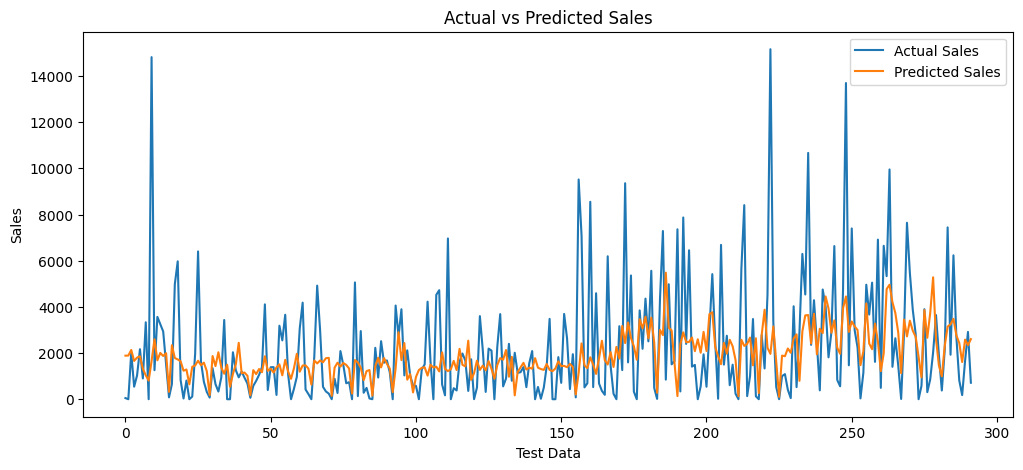

actual_vs_predicted.png saved successfully!


In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual Sales")
plt.plot(rf_pred_2, label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Data")
plt.ylabel("Sales")
plt.legend()

plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

print("actual_vs_predicted.png saved successfully!")

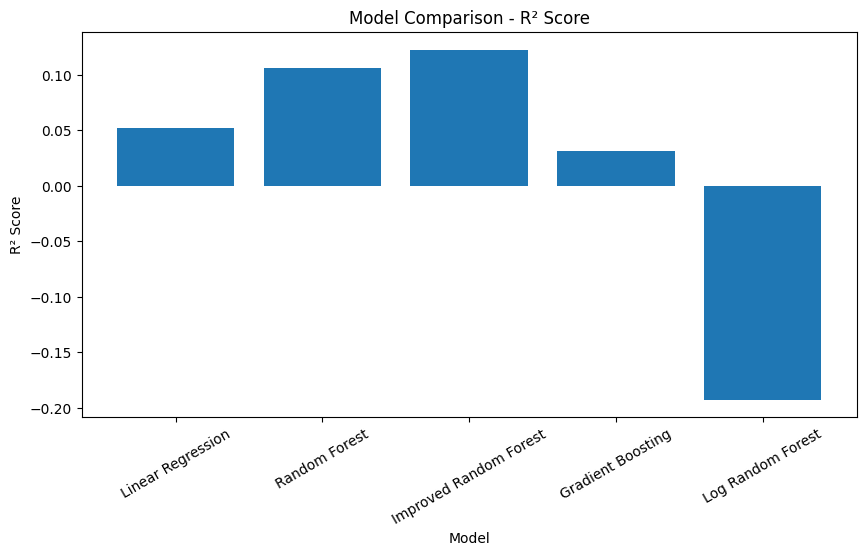

model_comparison.png saved successfully!


In [76]:
plt.figure(figsize=(10, 5))

plt.bar(final_comparison["Model"], final_comparison["R2"])

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=30)

plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("model_comparison.png saved successfully!")

In [77]:
import os

files = [
    "README.md",
    "sales_forecasting_model.pkl",
    "model_comparison.csv",
    "processed_sales_data.csv",
    "actual_vs_predicted.png",
    "model_comparison.png"
]

print("===== FINAL PROJECT FILES =====")

for file in files:
    if os.path.exists(file):
        size = os.path.getsize(file) / 1024
        print(f"✅ {file} — {size:.1f} KB")
    else:
        print(f"❌ {file} — NOT FOUND")

===== FINAL PROJECT FILES =====
✅ README.md — 3.8 KB
✅ sales_forecasting_model.pkl — 9800.7 KB
✅ model_comparison.csv — 0.4 KB
✅ processed_sales_data.csv — 2312.9 KB
✅ actual_vs_predicted.png — 418.9 KB
✅ model_comparison.png — 168.0 KB


In [78]:
import os

project_folder = "sales-forecasting-ml"

os.makedirs(project_folder, exist_ok=True)
os.makedirs(os.path.join(project_folder, "images"), exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [79]:
import shutil
import os

# Main project files
main_files = [
    "README.md",
    "model_comparison.csv",
    "processed_sales_data.csv",
    "sales_forecasting_model.pkl"
]

for file in main_files:
    shutil.copy(file, "sales-forecasting-ml")

# Visualization files
image_files = [
    "actual_vs_predicted.png",
    "model_comparison.png"
]

for file in image_files:
    shutil.copy(file, "sales-forecasting-ml/images")

print("All project files copied successfully!")

All project files copied successfully!


In [80]:
import os

for root, dirs, files in os.walk("sales-forecasting-ml"):
    level = root.replace("sales-forecasting-ml", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    └── {file}")

sales-forecasting-ml/
    └── model_comparison.csv
    └── processed_sales_data.csv
    └── README.md
    └── sales_forecasting_model.pkl
    images/
        └── model_comparison.png
        └── actual_vs_predicted.png
